In [42]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore") 

In [43]:
df=pd.read_csv(r"C:\Data Science Learning\Projects\aqi-regression-analysis\dataset\city_day.csv")

In [44]:
df.head()

,City,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Delhi,1/1/2015,153.3,241.7,182.9,33.0,81.3,38.5,1.87,64.5,83.6,18.93,20.81,8.32,204.5,Severe
1,Mumbai,1/1/2015,70.5,312.7,195.0,42.0,122.5,31.5,7.22,83.8,108.0,2.01,19.41,2.86,60.9,Satisfactory
2,Chennai,1/1/2015,174.1,275.4,56.2,68.8,230.9,28.5,8.56,60.8,43.9,19.07,10.19,9.63,486.5,Severe
3,Kolkata,1/1/2015,477.2,543.9,14.1,76.4,225.9,45.6,2.41,42.1,171.1,9.31,11.65,9.39,174.4,Very Poor
4,Bangalore,1/1/2015,171.6,117.7,123.3,12.4,61.9,49.7,1.26,79.7,164.3,6.04,12.74,9.59,489.7,Good


In [45]:
df.isnull().sum()

City          0
Datetime      0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
Xylene        0
AQI           0
AQI_Bucket    0
dtype: int64

In [46]:
df["City"].nunique()

5

In [47]:
df["City"].unique()

array(['Delhi', 'Mumbai', 'Chennai', 'Kolkata', 'Bangalore'], dtype=object)

In [48]:
df.shape

(18265, 16)

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18265 entries, 0 to 18264
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        18265 non-null  object 
 1   Datetime    18265 non-null  object 
 2   PM2.5       18265 non-null  float64
 3   PM10        18265 non-null  float64
 4   NO          18265 non-null  float64
 5   NO2         18265 non-null  float64
 6   NOx         18265 non-null  float64
 7   NH3         18265 non-null  float64
 8   CO          18265 non-null  float64
 9   SO2         18265 non-null  float64
 10  O3          18265 non-null  float64
 11  Benzene     18265 non-null  float64
 12  Toluene     18265 non-null  float64
 13  Xylene      18265 non-null  float64
 14  AQI         18265 non-null  float64
 15  AQI_Bucket  18265 non-null  object 
dtypes: float64(13), object(3)
memory usage: 2.2+ MB


In [55]:
df.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000
mean,250.597695,299.442491,100.481035,75.415916,125.964079,25.065042,5.002451,49.835839,100.406740,10.070033,15.063365,4.996341,251.111382
std,144.460292,173.479906,57.774795,43.460066,72.403893,14.452019,2.889439,28.988739,57.591436,5.785282,8.619433,2.899152,144.502626
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,125.700000,150.100000,50.600000,37.700000,63.100000,12.600000,2.490000,24.400000,50.600000,5.080000,7.640000,2.510000,125.400000
50%,251.000000,300.300000,100.200000,76.000000,126.200000,25.300000,5.000000,49.900000,100.700000,10.080000,15.130000,4.960000,251.200000
75%,376.200000,450.000000,151.000000,113.200000,188.900000,37.600000,7.510000,75.100000,150.400000,15.110000,22.500000,7.530000,376.400000
max,499.900000,600.000000,200.000000,150.000000,250.000000,50.000000,10.000000,100.000000,200.000000,20.000000,30.000000,10.000000,500.000000


In [57]:
df.groupby("City")["AQI"].mean().sort_values()

City
Bangalore    249.767397
Chennai      250.338763
Kolkata      250.635396
Delhi        251.496304
Mumbai       253.319053
Name: AQI, dtype: float64

In [61]:
import seaborn as sns

In [81]:
df.corr(numeric_only=True)

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
PM2.5,1.000000,-0.024813,-0.003121,0.006602,0.002993,0.005980,0.009632,0.009056,0.008475,-0.005903,-0.001193,-0.000789,0.000655
PM10,-0.024813,1.000000,0.002387,0.003604,-0.004637,0.000810,-0.007387,0.011537,-0.005494,0.010281,-0.000298,0.003054,0.001245
NO,-0.003121,0.002387,1.000000,-0.003365,0.001329,0.001598,-0.006056,-0.001321,-0.013673,0.004133,-0.008743,0.012211,0.001923
NO2,0.006602,0.003604,-0.003365,1.000000,0.001451,-0.006045,0.009833,-0.011502,0.003424,-0.000592,-0.000614,0.001536,0.011124
NOx,0.002993,-0.004637,0.001329,0.001451,1.000000,-0.003423,-0.000832,-0.017316,0.005907,-0.009426,-0.004565,-0.006419,-0.002662
NH3,0.005980,0.000810,0.001598,-0.006045,-0.003423,1.000000,-0.003939,0.001580,-0.002883,-0.007184,0.009687,0.001106,0.008079
CO,0.009632,-0.007387,-0.006056,0.009833,-0.000832,-0.003939,1.000000,-0.004426,-0.001052,0.005302,-0.004776,0.011416,0.006046
SO2,0.009056,0.011537,-0.001321,-0.011502,-0.017316,0.001580,-0.004426,1.000000,0.000546,-0.006330,0.001071,0.003771,0.002949
O3,0.008475,-0.005494,-0.013673,0.003424,0.005907,-0.002883,-0.001052,0.000546,1.000000,-0.006981,0.002540,-0.000982,0.000591
Benzene,-0.005903,0.010281,0.004133,-0.000592,-0.009426,-0.007184,0.005302,-0.006330,-0.006981,1.000000,-0.004351,-0.011459,-0.001251


In [101]:
df.columns

Index(['City', 'Datetime', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO',
       'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket'],
      dtype='object')

In [85]:
df['AQI_Bucket'].value_counts()

AQI_Bucket
Severe          3121
Satisfactory    3098
Good            3094
Poor            3016
Very Poor       2989
Moderate        2947
Name: count, dtype: int64

In [89]:
city_aqi=df.groupby("City")["AQI"].mean()
city_aqi

City
Bangalore    249.767397
Chennai      250.338763
Delhi        251.496304
Kolkata      250.635396
Mumbai       253.319053
Name: AQI, dtype: float64

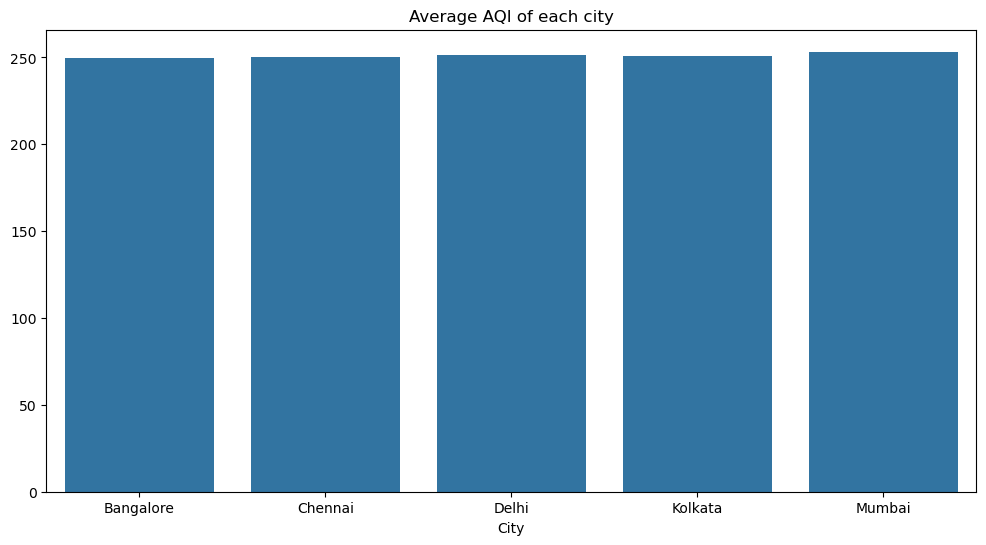

In [97]:

plt.figure(figsize=(12,6))
sns.barplot(x=city_aqi.index,y=city_aqi.values)
plt.title("Average AQI of each city")
plt.show()

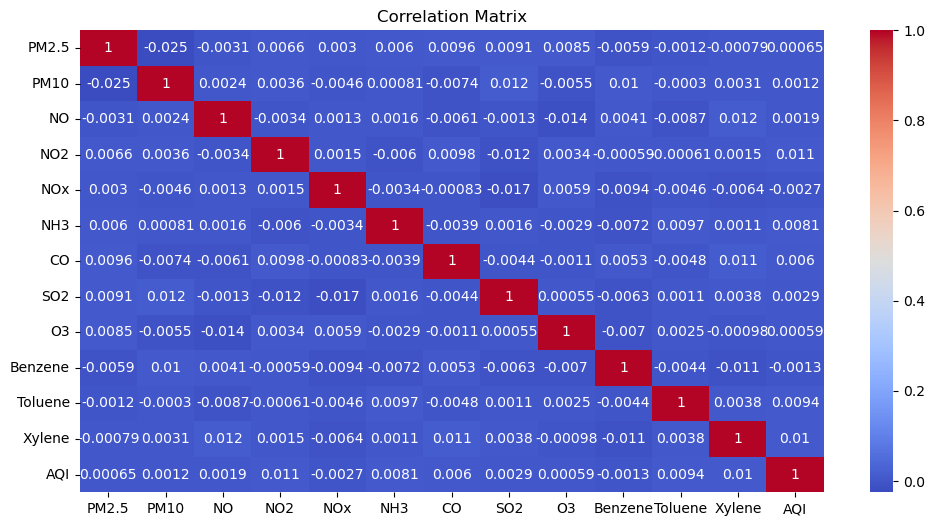

In [103]:
#Correlation Matrix
plt.figure(figsize=(12,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [105]:
#AQI vs Each Pollutant